## Medidas de concentración

### Preinstalación de matplotlib

In [10]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


### Preprocesamiento de DataFrame

In [11]:
import sys
from pathlib import Path
import polars as pl

#Para poder utilizar archivos del proyecto
ROOT = Path.cwd().parent 
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.cleaning.preprocessing import pipeline_preprocesamiento

df = pipeline_preprocesamiento()

### Coeficiente de Gini

In [12]:
n = entidades_df.height
entidades_df = entidades_df.with_columns(
    i=pl.int_range(1, n + 1, dtype=pl.Int64)
)

# 3. Cálculo del Coeficiente de Gini con Polars
sum_x = entidades_df["total_casos_pond"].sum()
sum_ix = (entidades_df["i"] * entidades_df["total_casos_pond"]).sum()

# Fórmula: G = (2 * sum(i * x) - (n + 1) * sum(x)) / (n * sum(x))
gini = (2 * sum_ix - (n + 1) * sum_x) / (n * sum_x)

print(f"Coeficiente obtenido: {gini:.6f}")

Coeficiente obtenido: 0.417820


### Curva de Lorenz

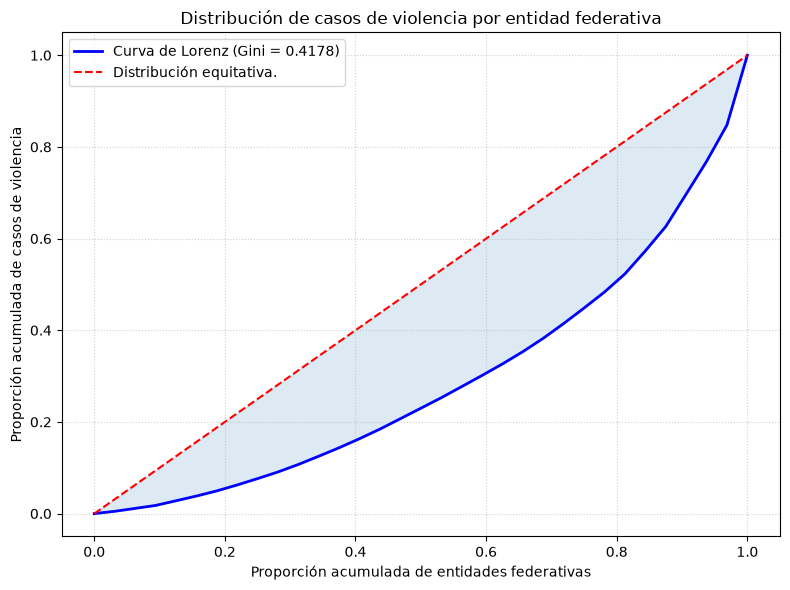

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# 1. Agregación ponderada y ordenamiento ascendente por entidad
entidades_df = (
    df.with_columns(
        (pl.col("sufrio_violencia_pareja") * pl.col("factor_expansion")).alias(
            "casos_ponderados"
        )
    )
    .group_by("nom_entidad")
    .agg(pl.col("casos_ponderados").sum().alias("total_casos_pond"))
    .sort("total_casos_pond")
)

# 4. Coordenadas de la Curva de Lorenz
x = entidades_df["total_casos_pond"].to_numpy()
prop_entidades = np.linspace(0, 1, n + 1)
prop_casos = np.insert(np.cumsum(x) / sum_x, 0, 0)

# 5. Graficar la Curva de Lorenz
plt.figure(figsize=(8, 6))
plt.plot(
    prop_entidades,
    prop_casos,
    color="blue",
    lw=2,
    label=f"Curva de Lorenz (Gini = {gini:.4f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    color="red",
    linestyle="--",
    lw=1.5,
    label="Distribución equitativa.",
)
plt.fill_between(
    prop_entidades, prop_entidades, prop_casos, color="#1f77b4", alpha=0.15
)

plt.title("Distribución de casos de violencia por entidad federativa")
plt.xlabel("Proporción acumulada de entidades federativas")
plt.ylabel("Proporción acumulada de casos de violencia")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

### Aplicación simultánea de entropía y coeficiente de Gini

In [14]:
# 1. Agrupar, ordenar de forma ascendente por frecuencia y calcular proporciones
frecuencias = (
    df.group_by("estrato_socioeconomico")
    .agg(n=pl.len())
    .sort("n")
    .with_columns(p=pl.col("n") / pl.col("n").sum())
)

K = frecuencias.height
N = frecuencias["n"].sum()

# 2. Entropía de Shannon
p_array = frecuencias["p"].to_numpy()
shannon_bits = -np.sum(p_array * np.log2(p_array))
shannon_max = np.log2(K)
shannon_rel = shannon_bits / shannon_max

# 3. Coeficiente de Gini sobre las frecuencias de las categorías (x_i ordenado)
x = frecuencias["n"].to_numpy()
i = np.arange(1, K + 1)
sum_x = np.sum(x)
sum_ix = np.sum(i * x)

gini_frecuencias = (2 * sum_ix - (K + 1) * sum_x) / (K * sum_x)

# 4. Construcción de la tabla resumida
resumen_estrato = pl.DataFrame(
    {
        "Variable": ["estrato_socioeconomico"],
        "Categorías (K)": [K],
        "Entropía Shannon (bits)": [round(shannon_bits, 4)],
        "Entropía Máxima (bits)": [round(shannon_max, 4)],
        "Entropía Relativa": [f"{shannon_rel * 100:.2f}%"],
        "Gini Frecuencias": [round(gini_frecuencias, 4)],
    }
)

print(resumen_estrato)

shape: (1, 6)
┌────────────────────┬───────────────────┬───────────┬───────────────────┬───────────┬─────────────┐
│ Variable           ┆ Categorías (K)    ┆ Entropía  ┆ Entropía Máxima   ┆ Entropía  ┆ Gini        │
│ ---                ┆ ---               ┆ Shannon   ┆ (bits)            ┆ Relativa  ┆ Frecuencias │
│ str                ┆ i64               ┆ (bits)    ┆ ---               ┆ ---       ┆ ---         │
│                    ┆                   ┆ ---       ┆ f64               ┆ str       ┆ f64         │
│                    ┆                   ┆ f64       ┆                   ┆           ┆             │
╞════════════════════╪═══════════════════╪═══════════╪═══════════════════╪═══════════╪═════════════╡
│ estrato_socioecono ┆ 4                 ┆ 1.7169    ┆ 2.0               ┆ 85.84%    ┆ 0.3294      │
│ mico               ┆                   ┆           ┆                   ┆           ┆             │
└────────────────────┴───────────────────┴───────────┴───────────────────┴───